In [1]:
import pandas as pd
import numpy as np

In [5]:
df_hazard1  = pd.read_excel("/content/pricing_worker_compensation (1).xlsx", sheet_name = "segment_summary")


--- Menjalankan Simulasi PV untuk Worker's Compensation ---


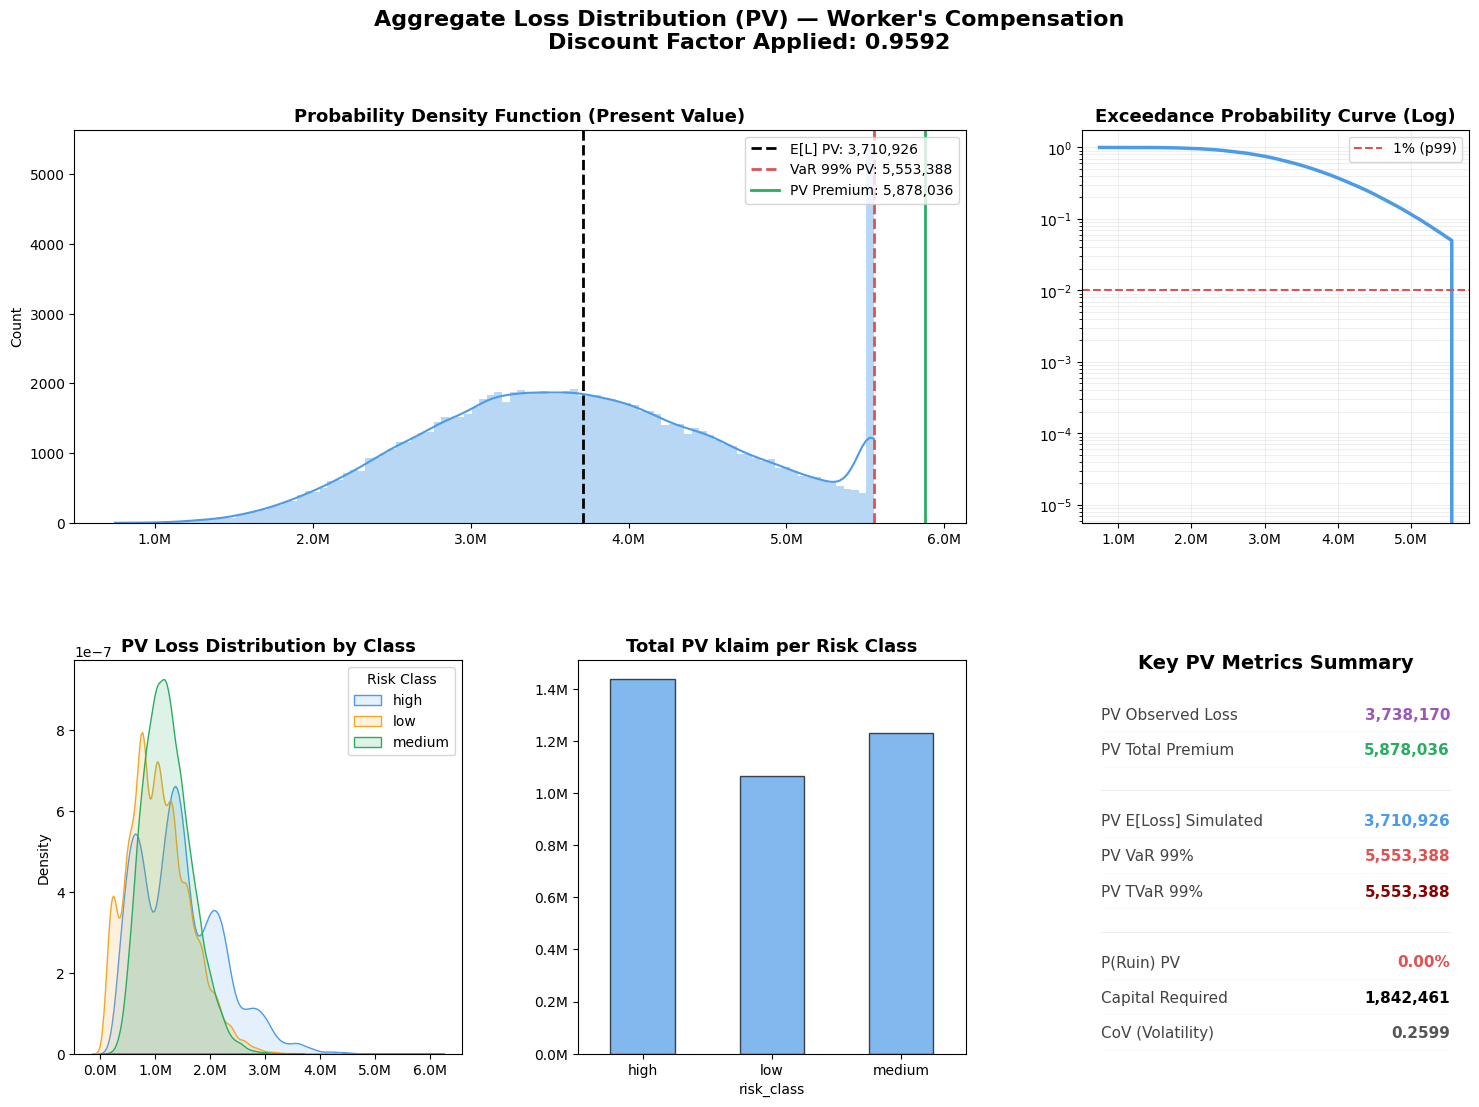


✅ Dashboard PV untuk Worker's Compensation berhasil dibuat dengan Discount Factor 0.959166.


In [10]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')

# =============================================================================
# 1. KONFIGURASI & INPUT DATA
# =============================================================================
HAZARD_NAME = "Worker's Compensation"
N_SIM       = 100_000
SEED        = 42
np.random.seed(SEED)

# MASUKKAN DISCOUNT FACTOR DI SINI
#
DISCOUNT_FACTOR = 0.959166

# =============================================================================
# 2. BOOTSTRAP SIMULATION (LOGIKA PRESENT VALUE)
# =============================================================================
print(f"--- Menjalankan Simulasi PV untuk {HAZARD_NAME} ---")

klaim_values = df_hazard1['klaim'].values
n_groups     = len(klaim_values)

# Bootstrap Aggregate Portfolio (Nominal -> PV)
agg_losses_pv = np.array([
    np.random.choice(klaim_values, size=n_groups, replace=True).sum()
    for _ in range(N_SIM)
]) * DISCOUNT_FACTOR


# 1. Hitung batas P95 dari simulasi kerugian kotor (Gross Loss)
p95_gross_pv = np.percentile(agg_losses_pv, 95)

# 2. Set Retention Limit di angka P95 tersebut
RETENTION_LIMIT = p95_gross_pv
agg_losses_pv = np.minimum(agg_losses_pv, RETENTION_LIMIT)

# Bootstrap per Risk Class (Nominal -> PV)
seg_losses_pv = {}
for rc in sorted(df_hazard1['risk_class'].unique()):
    vals = df_hazard1[df_hazard1['risk_class'] == rc]['klaim'].values
    n    = len(vals)
    seg_losses_pv[rc] = np.array([
        np.random.choice(vals, size=n, replace=True).sum()
        for _ in range(N_SIM)
    ]) * DISCOUNT_FACTOR

# =============================================================================
# 3. METRICS CALCULATION (BASED ON PV)
# =============================================================================
# Konversi data observasi ke PV
obs_loss_pv      = df_hazard1['klaim'].sum() * DISCOUNT_FACTOR
total_premium_pv = df_hazard1['earned_premium'].sum() * DISCOUNT_FACTOR

mean_loss_pv   = agg_losses_pv.mean()
std_loss_pv    = agg_losses_pv.std()
p95_pv         = np.percentile(agg_losses_pv, 95)
p99_pv         = np.percentile(agg_losses_pv, 99)
tvar99_pv      = agg_losses_pv[agg_losses_pv >= p99_pv].mean()
prob_ruin      = (agg_losses_pv > total_premium_pv).mean()
req_capital    = p99_pv - mean_loss_pv
cov            = std_loss_pv / mean_loss_pv

# =============================================================================
# 4. VISUALISASI DASHBOARD 5-PANEL
# =============================================================================
BLUE, RED, GREEN, ORANGE, PURPLE = '#4C9BE8', '#E05252', '#27AE60', '#F4A623', '#9B59B6'
GRAY, DARK_RED = '#888888', '#8B0000'

fig = plt.figure(figsize=(18, 12))
fig.suptitle(f"Aggregate Loss Distribution (PV) — {HAZARD_NAME}\n"
             f"Discount Factor Applied: {DISCOUNT_FACTOR:.4f}",
             fontsize=16, fontweight='bold', y=0.98)

gs = gridspec.GridSpec(2, 3, figure=fig, hspace=0.35, wspace=0.3)
fmt = plt.FuncFormatter(lambda x, _: f'{x/1e6:.1f}M')

# --- Panel 1: PDF Aggregate Loss (PV) ---
ax1 = fig.add_subplot(gs[0, :2])
sns.histplot(agg_losses_pv, bins=100, kde=True, ax=ax1, color=BLUE, alpha=0.4, edgecolor='none')
ax1.axvline(mean_loss_pv, color='black', lw=2, ls='--', label=f'E[L] PV: {mean_loss_pv:,.0f}')
ax1.axvline(p99_pv, color=RED, lw=2, ls='--', label=f'VaR 99% PV: {p99_pv:,.0f}')
ax1.axvline(total_premium_pv, color=GREEN, lw=2, label=f'PV Premium: {total_premium_pv:,.0f}')
ax1.set_title('Probability Density Function (Present Value)', fontsize=13, fontweight='bold')
ax1.xaxis.set_major_formatter(fmt)
ax1.legend(loc='upper right')

# --- Panel 2: Exceedance Probability (Log Scale) ---
ax2 = fig.add_subplot(gs[0, 2])
sorted_pv = np.sort(agg_losses_pv)
survival = 1 - np.arange(1, len(sorted_pv) + 1) / len(sorted_pv)
ax2.plot(sorted_pv, survival, color=BLUE, lw=2.5)
ax2.axhline(0.01, color=RED, ls='--', label='1% (p99)')
ax2.set_yscale('log')
ax2.set_title('Exceedance Probability Curve (Log)', fontsize=13, fontweight='bold')
ax2.xaxis.set_major_formatter(fmt)
ax2.grid(True, alpha=0.2, which='both')
ax2.legend()

# --- Panel 3: PV Loss by Risk Class (KDE) ---
ax3 = fig.add_subplot(gs[1, 0])
colors_p = [BLUE, ORANGE, GREEN, PURPLE, RED]
for i, (rc, losses) in enumerate(seg_losses_pv.items()):
    sns.kdeplot(losses, ax=ax3, label=rc, color=colors_p[i % 5], fill=True, alpha=0.15)
ax3.set_title('PV Loss Distribution by Class', fontsize=13, fontweight='bold')
ax3.xaxis.set_major_formatter(fmt)
ax3.legend(title="Risk Class")

# --- Panel 4: Total PV klaim per Class (Bar) ---
ax4 = fig.add_subplot(gs[1, 1])
rc_summary = df_hazard1.groupby('risk_class')['klaim'].sum() * DISCOUNT_FACTOR
rc_summary.plot(kind='bar', ax=ax4, color=BLUE, alpha=0.7, edgecolor='black')
ax4.set_title('Total PV klaim per Risk Class', fontsize=13, fontweight='bold')
ax4.yaxis.set_major_formatter(fmt)
plt.xticks(rotation=0)

# --- Panel 5: Key PV Metrics Summary ---
ax5 = fig.add_subplot(gs[1, 2])
ax5.axis('off')

metrics_list = [
    ("PV Observed Loss", f"{obs_loss_pv:,.0f}", PURPLE),
    ("PV Total Premium", f"{total_premium_pv:,.0f}", GREEN),
    ("------------------", "", GRAY),
    ("PV E[Loss] Simulated", f"{mean_loss_pv:,.0f}", BLUE),
    ("PV VaR 99%", f"{p99_pv:,.0f}", RED),
    ("PV TVaR 99%", f"{tvar99_pv:,.0f}", DARK_RED),
    ("------------------", "", GRAY),
    ("P(Ruin) PV", f"{prob_ruin:.2%}", RED),
    ("Capital Required", f"{req_capital:,.0f}", 'black'),
    ("CoV (Volatility)", f"{cov:.4f}", '#555555')
]

ax5.text(0.5, 0.98, 'Key PV Metrics Summary', fontsize=14, fontweight='bold', ha='center')
y_pos = 0.85
for label, val, col in metrics_list:
    if label == "------------------":
        ax5.axhline(y_pos, color='#EEEEEE', lw=0.8, xmin=0.05, xmax=0.95)
    else:
        ax5.text(0.05, y_pos, label, fontsize=11, color='#444444')
        ax5.text(0.95, y_pos, val, fontsize=11, fontweight='bold', color=col, ha='right')
        ax5.axhline(y_pos - 0.03, color='#F9F9F9', lw=0.5, xmin=0.05, xmax=0.95)
    y_pos -= 0.09

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

print(f"\n✅ Dashboard PV untuk {HAZARD_NAME} berhasil dibuat dengan Discount Factor {DISCOUNT_FACTOR}.")